In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import json
import sys
sys.path.append('/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder')
import utils as ut
import evaluation
from matplotlib.patches import Patch


In [4]:
import torch
quantiles = torch.linspace(0,0.95,20)
quantiles

tensor([0.0000, 0.0500, 0.1000, 0.1500, 0.2000, 0.2500, 0.3000, 0.3500, 0.4000,
        0.4500, 0.5000, 0.5500, 0.6000, 0.6500, 0.7000, 0.7500, 0.8000, 0.8500,
        0.9000, 0.9500])

## Validation set

In [5]:
import numpy as np
np.mean(np.zeros((10,19)), axis=0).shape

(19,)

In [ ]:
# load DPA
# v5
#dpa_ensemble = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v5_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue/validation_set_reference_period_1950-1980_v5_dpa_train_settings.json/dpa_ensemble_after_20_epochs/eth_ensemble_after_20_epochs/raw_ETH_gen_dpa_ens_20_dataset.nc")

# v5 model4, 50 epochs slowly trained
#dpa_ensemble = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v5_model/_50_4_50_5_1001_100_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisTrue_lr5e-05_50epochs/validation_set_reference_period_1950-1980_v5_dpa_train_settings.json/dpa_ensemble_after_50_epochs/eth_ensemble_after_50_epochs/raw_ETH_gen_dpa_ens_50_dataset.nc")

# v5 model4, more epochs slowly trained
#dpa_ensemble = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v5_model/_50_4_50_5_1001_100_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisTrue_lr5e-05/validation_set_reference_period_1950-1980_v5_dpa_train_settings.json/dpa_ensemble_after_100_epochs/eth_ensemble_after_100_epochs/raw_ETH_gen_dpa_ens_100_dataset.nc")


# v5 data, pene False, bnFalse model _devicecpu100_6_100_100_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisFalse_lr0.0001_pene0
dpa_ensemble=xr.open_dataset("")

# v6
# good!
#dpa_ensemble = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v6_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_50epochs/validation_set_reference_period_1950-1980_v6_dpa_train_settings.json/dpa_ensemble_after_30_epochs/eth_ensemble_after_30_epochs/raw_ETH_gen_dpa_ens_30_dataset.nc")
# mean bias = 0.1563122272491455


# penalty_e is TRUE, 30 epochs
#dpa_ensemble = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v6_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_lr5e-05_peneTrue/validation_set_reference_period_1950-1980_v6_dpa_train_settings.json/dpa_ensemble_after_30_epochs/eth_ensemble_after_30_epochs/raw_ETH_gen_dpa_ens_30_dataset.nc")
# validation mean bias = 0.43983542919158936
# Q-Q MAE: 0.4379359421957482
# C-Q MAE: 0.19274039575768942
# validation R^2:0.865289032459259

# penalty_e is TRUE, 45 epochs
#dpa_ensemble = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v6_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_lr5e-05_peneTrue/validation_set_reference_period_1950-1980_v6_dpa_train_settings.json/dpa_ensemble_after_45_epochs/eth_ensemble_after_45_epochs/raw_ETH_gen_dpa_ens_45_dataset.nc")
# mean bias = 0.14442193508148193
# Q-Q MAE: 0.18549036518915707
# C-Q MAE: 0.06543134939466506

# penalty_e is FALSE, 30 epochs
#dpa_ensemble = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v6_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_lr5e-05_peneFalse/validation_set_reference_period_1950-1980_v6_dpa_train_settings.json/dpa_ensemble_after_30_epochs/eth_ensemble_after_30_epochs/raw_ETH_gen_dpa_ens_30_dataset.nc")
# validation mean bias = 0.01291346549987793
# Q-Q MAE: 0.11992518042067157
# C-Q MAE: 0.012872609285848302

# penalty_e is FALSE, 45 epochs
#dpa_ensemble = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v6_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_lr5e-05_peneFalse/validation_set_reference_period_1950-1980_v6_dpa_train_settings.json/dpa_ensemble_after_45_epochs/eth_ensemble_after_45_epochs/raw_ETH_gen_dpa_ens_45_dataset.nc")
# validation mean bias = 0.010464191436767578
# THIS ONE SEEMS TO HAVE THE LEAST BIAS
# Q-Q MAE: 0.11780215825542378
# C-Q MAE: 0.01921289909613627

# checkout: penalty_e is FALSE, 45 epochs

# penalty_e is false, batch norm is false
#dpa_ensemble = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v6_data_model5/_devicecpu100_6_100_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisFalse_lr0.0001/model5_validation_set_reference_period_1950-1980_v6_dpa_train_settings.json/dpa_ensemble_after_50_epochs/eth_ensemble_after_50_epochs/raw_ETH_gen_dpa_ens_50_dataset.nc")



# v6 slowly trained
#dpa_ensemble = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v6_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_lr5e-05/validation_set_reference_period_1950-1980_v6_dpa_train_settings.json/dpa_ensemble_after_30_epochs/eth_ensemble_after_30_epochs/raw_ETH_gen_dpa_ens_30_dataset.nc")
# mean bias = 0.28885388374328613


dpa_ensemble


In [3]:
# dpa spatial mean
dpa_ensemble_spat_mean = dpa_ensemble.TREFHT.mean(dim="lat_x_lon")
dpa_ensemble_spat_mean

<xarray.DataArray 'TREFHT' (ensemble_member: 100, time: 47690)> Size: 19MB
array([[ 0.6483562 ,  0.08923076,  0.4616962 , ...,  7.5542684 ,
         6.4266915 ,  7.579421  ],
       [-0.59035945, -1.0645561 ,  1.9241043 , ...,  8.7801285 ,
         6.3355594 ,  7.5491967 ],
       [-1.1915816 , -0.64282036,  0.9954543 , ...,  7.399001  ,
         7.0436845 ,  7.82095   ],
       ...,
       [ 0.1410092 , -0.8975504 ,  1.5559741 , ...,  9.14062   ,
         5.9397116 ,  7.0701942 ],
       [-0.28470498, -0.66551656,  0.90487105, ...,  7.803167  ,
         7.3555713 ,  7.911967  ],
       [-0.7283367 , -1.012554  ,  1.6340692 , ...,  6.036009  ,
         7.202664  ,  8.324239  ]], shape=(100, 47690), dtype=float32)
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 1 2 3 4 5 ... 96 97 98 99 100
  * time             (time) object 382kB 1850-06-02 00:00:00 ... 2100-08-31 0...

In [4]:
dpa_ensemble_mean_spat_mean = dpa_ensemble_spat_mean.mean(dim="ensemble_member")
dpa_ensemble_mean_spat_mean

<xarray.DataArray 'TREFHT' (time: 47690)> Size: 191kB
array([-0.43005776, -0.51375693,  1.2015058 , ...,  7.2461634 ,
        6.809076  ,  7.5886064 ], shape=(47690,), dtype=float32)
Coordinates:
  * time     (time) object 382kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00

In [5]:
# v5
#settings_file_path = "/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/v5_dpa_train_settings.json"

# v6
#settings_file_path = "/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/v6_dpa_train_settings.json"


with open(settings_file_path, 'r') as file:
    settings = json.load(file)
  
# Save to a new file for logging
with open(f"used_settings.json", "w") as f:
    json.dump(settings, f, indent=4)

# Load temperature data
ds = xr.open_dataset(settings['dataset_trefht'])
print("Dataset:", settings['dataset_trefht'])

# set train/test split
#ds_train = ds.isel(time=slice(0, 4769 * 90)) #
ds_test = ds.isel(time=slice(4769 * 90, 476900)) #4769 * 80

# transform to torch tensors
#x_tr = ut.data_to_torch(ds_train, "TREFHT")
x_te = ut.data_to_torch(ds_test, "TREFHT")

# remove NaNs from Temperature data
#x_tr_reduced, mask_x_tr = ut.remove_nan_columns(x_tr)
x_te_reduced, mask_x_te = ut.remove_nan_columns(x_te)
x_te_reduced

Dataset: /work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_input_data/v6_starting03022026/europe_10percent_masked_stacked_TREFHT_JJA.nc
torch.Size([47690, 1024])


tensor([[ 0.0174, -1.8732, -2.9070,  ...,  3.6220,  3.8387,  4.1475],
        [-2.7454, -4.9564, -5.4752,  ...,  0.1563,  0.4759,  0.8389],
        [-0.4858, -1.3552, -1.5081,  ...,  5.0021,  5.5319,  5.9963],
        ...,
        [ 8.7707, 11.4248, 11.2811,  ..., 10.0561, 10.0342, 10.7967],
        [ 1.8876,  6.5189,  8.4209,  ...,  8.0466,  8.6535,  9.4135],
        [-5.0652, -1.0113,  0.8786,  ...,  8.2254,  8.2602,  8.3437]])

In [7]:
x_te_reduced.shape

torch.Size([47690, 648])

In [6]:
x_te_reduced_mean = x_te_reduced.mean(dim=1)

In [7]:
from matplotlib.patches import Patch
# both to numpy
dpa = dpa_ensemble_mean_spat_mean.values
test = x_te_reduced_mean.detach().cpu().numpy()
print(dpa.shape)
print(test.shape)


(47690,)
(47690,)


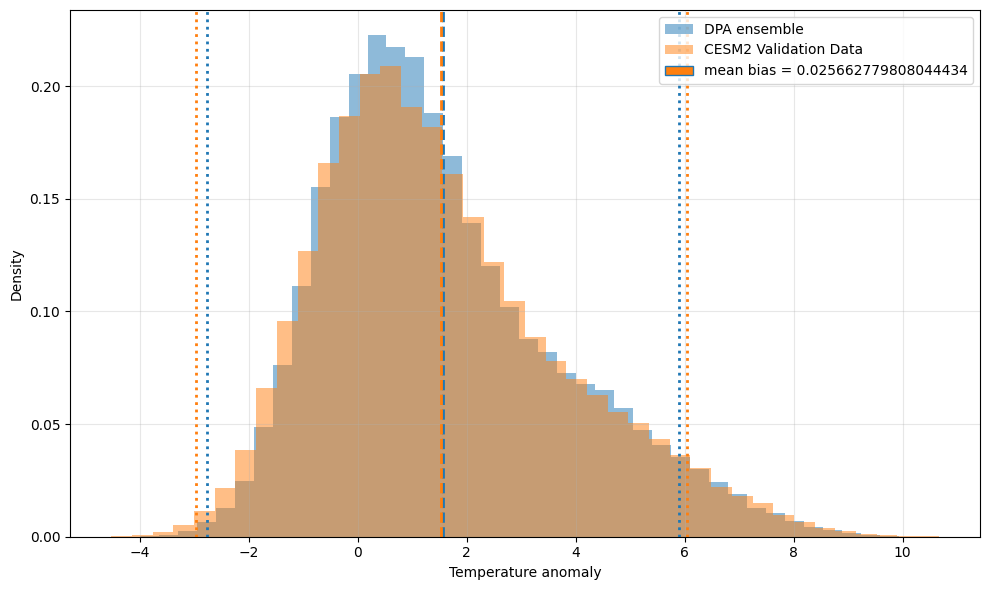

Quantiles: [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]


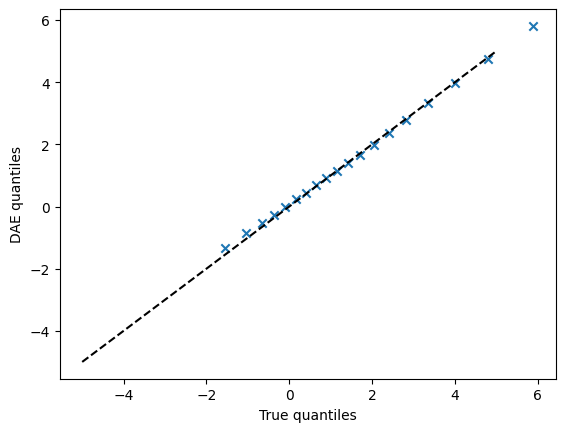

Q-Q MAE: 0.0680317627976794
(47690,)
(19, 47690)
[0.07615852 0.12847557 0.17957643 0.22992242 0.27701824 0.32566576
 0.37301321 0.42147201 0.46875655 0.51589432 0.56043196 0.60725519
 0.65472845 0.70169847 0.74793458 0.79488362 0.84122458 0.88857203
 0.93816314]
C-Q MAE: 0.016278376797519062


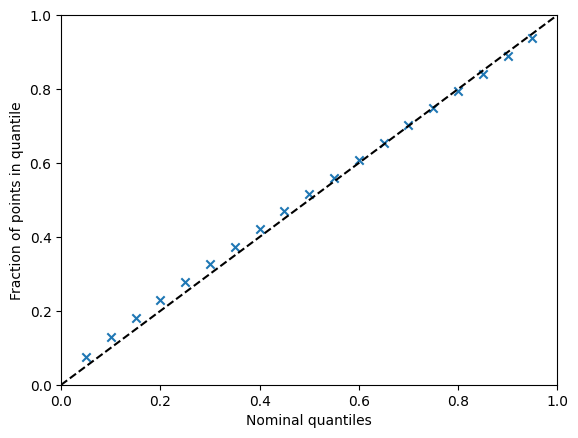

In [8]:
from matplotlib.patches import Patch

# Example data
# x1, x2 should be 1D arrays
x1 = dpa
x2 = test

fig, ax = plt.subplots(figsize=(10, 6))

# Histogram (density=True → normalized)
ax.hist(x1, bins=40, density=True, alpha=0.5, label="DPA ensemble")
ax.hist(x2, bins=40, density=True, alpha=0.5, label="CESM2 Validation Data")

# Compute statistics
mean1, std1 = np.mean(x1), np.std(x1)
mean2, std2 = np.mean(x2), np.std(x2)

# Add mean lines
ax.axvline(mean1, linestyle="--", linewidth=2, color="tab:blue")
ax.axvline(mean2, linestyle="--", linewidth=2, color ="tab:orange")

# Add ±2σ lines
ax.axvline(mean1 - 2*std1, linestyle=":", linewidth=2, color="tab:blue")
ax.axvline(mean1 + 2*std1, linestyle=":", linewidth=2, color="tab:blue")

ax.axvline(mean2 - 2*std2, linestyle=":", linewidth=2, color ="tab:orange")
ax.axvline(mean2 + 2*std2, linestyle=":", linewidth=2, color ="tab:orange")

ax.set_xlabel("Temperature anomaly")
ax.set_ylabel("Density")
#custom_patch = Patch(facecolor='tab:orange', edgecolor='tab:blue')
#ax.legend(handles=[custom_patch], labels=[f"mean bias = {np.abs(mean2 - mean1)}"])
custom_patch = Patch(
    facecolor='tab:orange',
    edgecolor='tab:blue'
)

# Get existing legend entries
handles, labels = ax.get_legend_handles_labels()

# Append your custom entry
handles.append(custom_patch)
labels.append(f"mean bias = {np.abs(mean2 - mean1)}")

# Rebuild legend
ax.legend(handles, labels)



ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig("compare_distrs_v6_30epochs_validation.pdf")
plt.show()

# compute and plot quantiles
#quantiles = np.linspace(0,1,20)
quantiles = np.arange(0.05,1,0.05)
print("Quantiles:", quantiles)
quantiles_dpa = np.quantile(dpa, quantiles)
quantiles_test = np.quantile(test, quantiles)
plt.scatter(quantiles_test, quantiles_dpa, marker='x')

# Example data
x = np.linspace(-5, 5, 100)
# Plot 1:1 line
plt.plot(x, x, color="black", linestyle="--")
plt.xlabel("True quantiles")
plt.ylabel("DAE quantiles")
#plt.savefig("Q-Q_v6_30epochs_validation.pdf")
plt.plot()
plt.show()
mae_qq = np.mean(np.abs(quantiles_test-quantiles_dpa))
print("Q-Q MAE:", mae_qq)


dpa_ensemble_spat_mean_quantiles = np.quantile(dpa_ensemble_spat_mean, quantiles, axis=0)
print(test.shape)
print(dpa_ensemble_spat_mean_quantiles.shape)
cover_dpa = evaluation.compute_coverage_per_quantile(test, dpa_ensemble_spat_mean_quantiles.T, quantiles)
print(cover_dpa)
plt.scatter(quantiles, cover_dpa, marker='x')
plt.plot(x, x, color="black", linestyle="--")
plt.xlim(0,1)
plt.ylim(0,1)
plt.ylabel("Fraction of points in quantile")
plt.xlabel("Nominal quantiles")
mae_cq = np.mean(np.abs(quantiles-cover_dpa))
print("C-Q MAE:", mae_cq)
#plt.savefig("cov_quants.pdf")

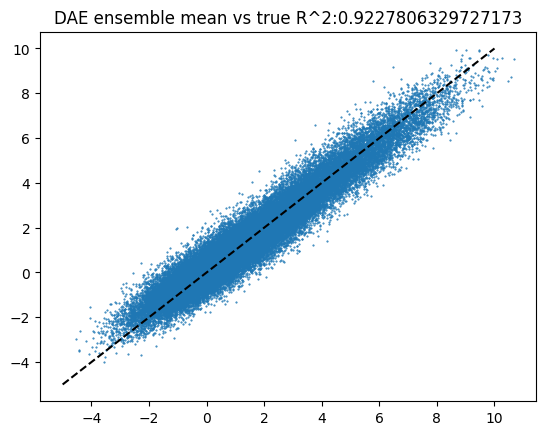

/home/sc.uni-leipzig.de/fl53wumy/.conda/envs/dpa/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


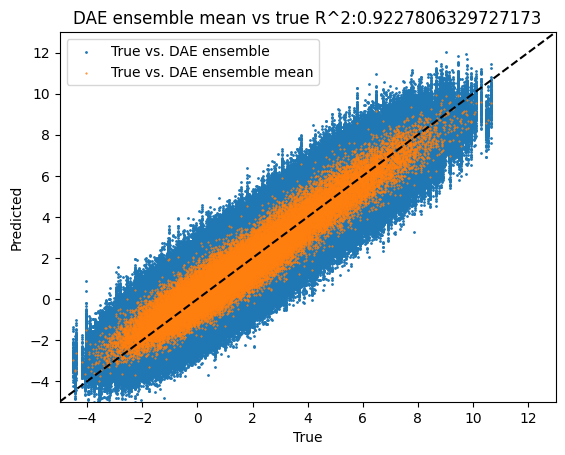

47690 100


In [9]:
# scatter predicted vs true
plt.scatter(test, dpa, marker='.', s=1)
x = np.linspace(-5, 10, 200)
# Plot 1:1 line
plt.plot(x, x, color="black", linestyle="--")
r2 = 1 - np.sum((test - dpa)**2) / np.sum((test - np.mean(test))**2)

plt.title(f"DAE ensemble mean vs true R^2:{r2}")
plt.show()

# Example shapes:
# y_true: (N,)
# y_pred: (N, 100) 
y_true = test
y_pred = dpa_ensemble_spat_mean.T.values

N, M = y_pred.shape  # M should be 100

x = np.repeat(y_true, M)     # shape (N*100,)
y = y_pred.flatten()         # shape (N*100,)

plt.scatter(x, y, s=1, label="True vs. DAE ensemble")
plt.scatter(test, dpa, marker='.', s=1, label = "True vs. DAE ensemble mean")
r2_ens = 1 - np.sum((test - dpa)**2) / np.sum((test - np.mean(test))**2)
x = np.linspace(-5, 13, 200)
# Plot 1:1 line
plt.plot(x, x, color="black", linestyle="--")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.xlim(-5,13)
plt.ylim(-5,13)
plt.title(f"DAE ensemble mean vs true R^2:{r2}")
plt.legend()
plt.show()

print(N,M)

## ETH test data

In [31]:
dpa_ensemble_spat_mean

<xarray.DataArray 'TREFHT' (ensemble_member: 100, time: 47690)> Size: 19MB
array([[-0.9406362 , -0.9927307 ,  0.80475426, ...,  7.7488832 ,
         7.999908  ,  7.3790326 ],
       [-0.5432884 , -0.22946411,  1.4941511 , ...,  9.405213  ,
         8.33194   ,  8.661043  ],
       [-1.1390085 , -2.318006  ,  1.3195796 , ...,  9.168898  ,
         6.6375656 ,  7.085696  ],
       ...,
       [ 0.8076281 , -2.028458  ,  1.8081905 , ...,  9.001689  ,
         6.179956  ,  7.7199736 ],
       [-1.1625762 , -2.3752708 ,  0.3714075 , ...,  8.503161  ,
         7.6170483 ,  7.120002  ],
       [ 0.42667097, -2.4094455 ,  1.955112  , ...,  6.1083894 ,
         7.8246603 ,  7.9055357 ]], shape=(100, 47690), dtype=float32)
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 1 2 3 4 5 ... 96 97 98 99 100
  * time             (time) object 382kB 1850-06-02 00:00:00 ... 2100-08-31 0...

In [ ]:
# bias between LE validatin and ETH test set: mean bias = 0.1348029375076294

# v6, model 3 penalty_e is FALSE, 30 epochs
#dpa_ensemble_eth_cf = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v6_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_lr5e-05_peneFalse/et_test_set_reference_period_1950-1980_v6_dpa_train_settings.json/dpa_ensemble_after_30_epochs/eth_ensemble_after_30_epochs/raw_ETH_cf_gen_dpa_ens_30_dataset.nc")
#dpa_ensemble_eth_fact = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v6_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_lr5e-05_peneFalse/et_test_set_reference_period_1950-1980_v6_dpa_train_settings.json/dpa_ensemble_after_30_epochs/eth_ensemble_after_30_epochs/raw_ETH_gen_dpa_ens_30_dataset.nc")
# factual mean bias = 0.1290351152420044
# factual R^2:0.8257062435150146
# factual Q-Q MAE: 0.16032480579849948
# factual C-Q MAE: 0.08230715181747622
# cf mean bias = 0.17454060912132263
# cf R^2:0.6851222515106201
# cf Q-Q MAE: 0.15236233704184246
# cf C-Q MAE: 0.08198710237535542

# v6, model 3 penalty_e is FALSE, 45 epochs
#dpa_ensemble_eth_cf = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v6_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_lr5e-05_peneFalse/eth_test_set_reference_period_1950-1980_v6_dpa_train_settings.json/dpa_ensemble_after_45_epochs/eth_ensemble_after_45_epochs/raw_ETH_cf_gen_dpa_ens_45_dataset.nc")
#dpa_ensemble_eth_fact = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v6_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_lr5e-05_peneFalse/eth_test_set_reference_period_1950-1980_v6_dpa_train_settings.json/dpa_ensemble_after_45_epochs/eth_ensemble_after_45_epochs/raw_ETH_gen_dpa_ens_45_dataset.nc")
# factual mean bias = 0.15550339221954346
# factual R^2:0.8219856023788452
# factual Q-Q MAE: 0.17695267624957003
# factual C-Q MAE: 0.09175780718308672
# cf mean bias = 0.14796355366706848
# cf R^2:0.6860218644142151
# cf Q-Q MAE: 0.1311998845715274
# cf C-Q MAE: 0.07231020516272857


# v6 data, model5, pene False, batchnormalization False
dpa_ensemble_eth_cf = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v6_data_model5/_devicecpu100_6_100_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisFalse_lr0.0001/model5_eth_test_set_reference_period_1950-1980_v6_dpa_train_settings.json/dpa_ensemble_after_50_epochs/eth_ensemble_after_50_epochs/raw_ETH_cf_gen_dpa_ens_50_dataset.nc")
dpa_ensemble_eth_fact = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v6_data_model5/_devicecpu100_6_100_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisFalse_lr0.0001/model5_eth_test_set_reference_period_1950-1980_v6_dpa_train_settings.json/dpa_ensemble_after_50_epochs/eth_ensemble_after_50_epochs/raw_ETH_gen_dpa_ens_50_dataset.nc")


dpa_ensemble_eth_cf

# dpa spatial mean

# fact
dpa_ensemble_spat_mean_fact = dpa_ensemble_eth_fact.TREFHT.mean(dim="lat_x_lon")
dpa_ensemble_mean_spat_mean_fact = dpa_ensemble_spat_mean_fact.mean(dim="ensemble_member")

# cf
dpa_ensemble_spat_mean_cf = dpa_ensemble_eth_cf.TREFHT.mean(dim="lat_x_lon")
dpa_ensemble_mean_spat_mean_cf = dpa_ensemble_spat_mean_cf.mean(dim="ensemble_member")
dpa_ensemble_mean_spat_mean_cf

In [12]:
dpa_ensemble_spat_mean_cf

<xarray.DataArray 'TREFHT' (ensemble_member: 100, time: 14307)> Size: 6MB
array([[-0.9928902 , -0.4969805 ,  0.47216204, ...,  0.5321527 ,
        -0.10466212, -0.0452951 ],
       [-1.6404004 , -0.37731013, -0.4538088 , ..., -0.1402347 ,
        -1.2666858 ,  0.9915922 ],
       [-2.5720935 ,  0.40674073,  1.764338  , ...,  1.7168617 ,
        -0.38127455,  0.10105597],
       ...,
       [-1.6692697 , -0.05126635, -0.7029402 , ..., -0.06994471,
        -0.2970861 , -1.4099321 ],
       [-2.254405  , -1.3842163 , -0.4447765 , ..., -0.03580074,
        -0.58031225, -0.08121604],
       [-2.4876008 ,  0.19154   , -1.6710923 , ...,  0.57330304,
        -0.3497048 , -0.6391618 ]], shape=(100, 14307), dtype=float32)
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 1 2 3 4 5 ... 96 97 98 99 100
  * time             (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 0...

In [ ]:
# FACT
# Load temperature data
ds_fact = xr.open_dataset(settings['dataset_trefht_eth_transient'])
print("Dataset:", settings['dataset_trefht_eth_transient'])

# set train/test split
#ds_train = ds.isel(time=slice(0, 4769 * 90)) #
ds_test_fact = ds_fact#.isel(time=slice(4769, 2*4769)) #4769 * 80

# transform to torch tensors
#x_tr = ut.data_to_torch(ds_train, "TREFHT")
x_te_fact = ut.data_to_torch(ds_test_fact, "TREFHT")

# remove NaNs from Temperature data
#x_tr_reduced, mask_x_tr = ut.remove_nan_columns(x_tr)
x_te_reduced_fact, mask_x_te = ut.remove_nan_columns(x_te_fact)
x_te_reduced_fact.shape

x_te_reduced_mean_fact = x_te_reduced_fact.mean(dim=1)

# CF
# Load temperature data
ds_cf = xr.open_dataset(settings['dataset_trefht_eth_nudged_shifted'])
print("Dataset:", settings['dataset_trefht_eth_nudged_shifted'])

# set train/test split
#ds_train = ds.isel(time=slice(0, 4769 * 90)) #
ds_test_cf = ds_cf#.isel(time=slice(4769, 2*4769)) #4769 * 80

# transform to torch tensors
#x_tr = ut.data_to_torch(ds_train, "TREFHT")
x_te_cf = ut.data_to_torch(ds_test_cf, "TREFHT")

# remove NaNs from Temperature data
#x_tr_reduced, mask_x_tr = ut.remove_nan_columns(x_tr)
x_te_reduced_cf, mask_x_te = ut.remove_nan_columns(x_te_cf)
x_te_reduced_cf.shape

x_te_reduced_mean_cf = x_te_reduced_cf.mean(dim=1)

# both to numpy
dpa_fact = dpa_ensemble_mean_spat_mean_fact.values
test_fact = x_te_reduced_mean_fact.detach().cpu().numpy()

# cf
dpa_cf = dpa_ensemble_mean_spat_mean_cf.values
test_cf = x_te_reduced_mean_cf.detach().cpu().numpy()

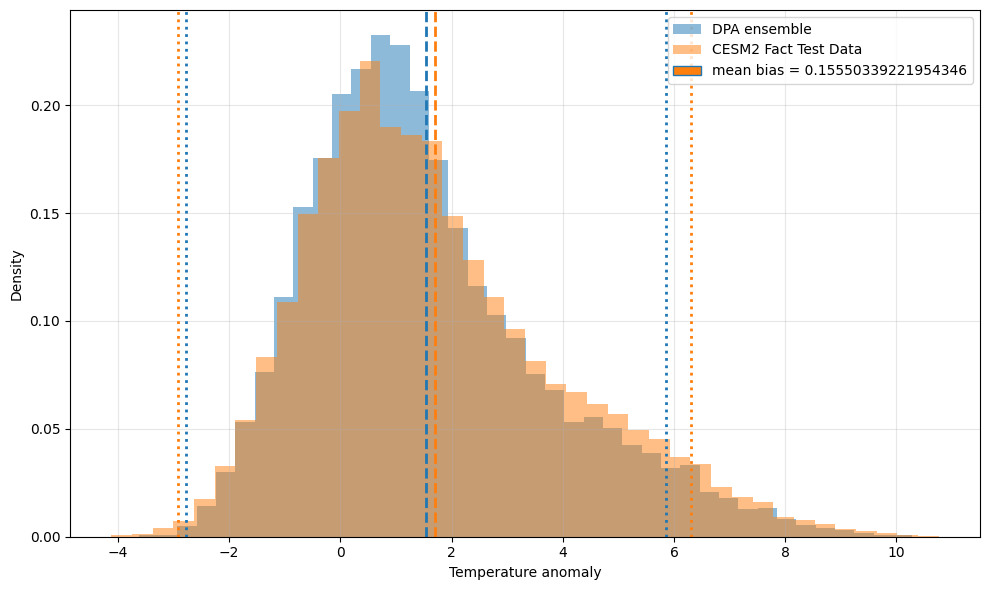

/home/sc.uni-leipzig.de/fl53wumy/.conda/envs/dpa/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


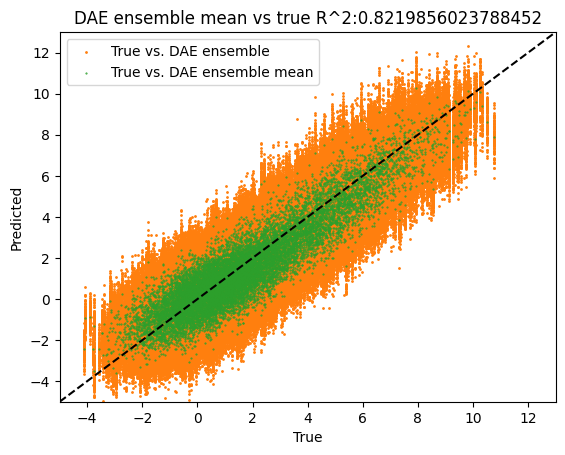

Quantiles: [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]


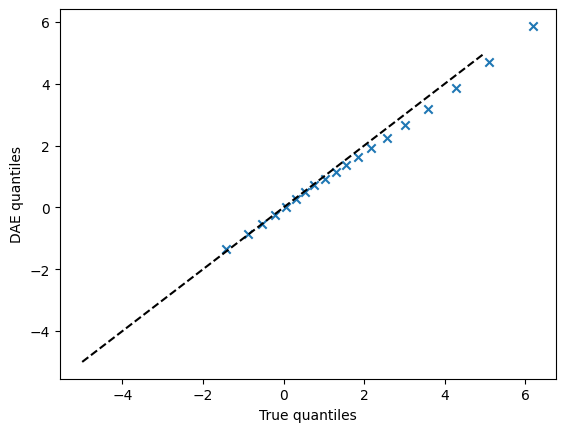

Q-Q MAE: 0.17695267624957003
C-Q MAE: 0.09175780718308672


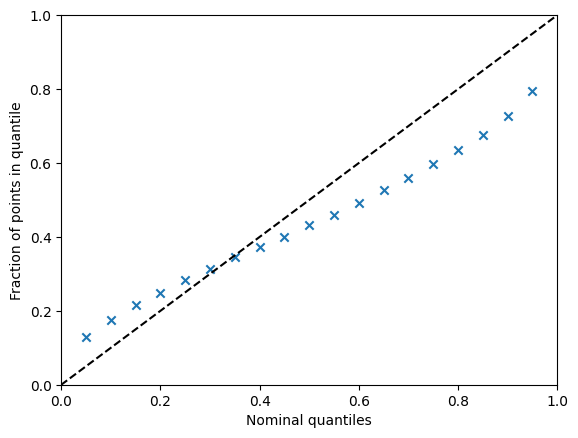

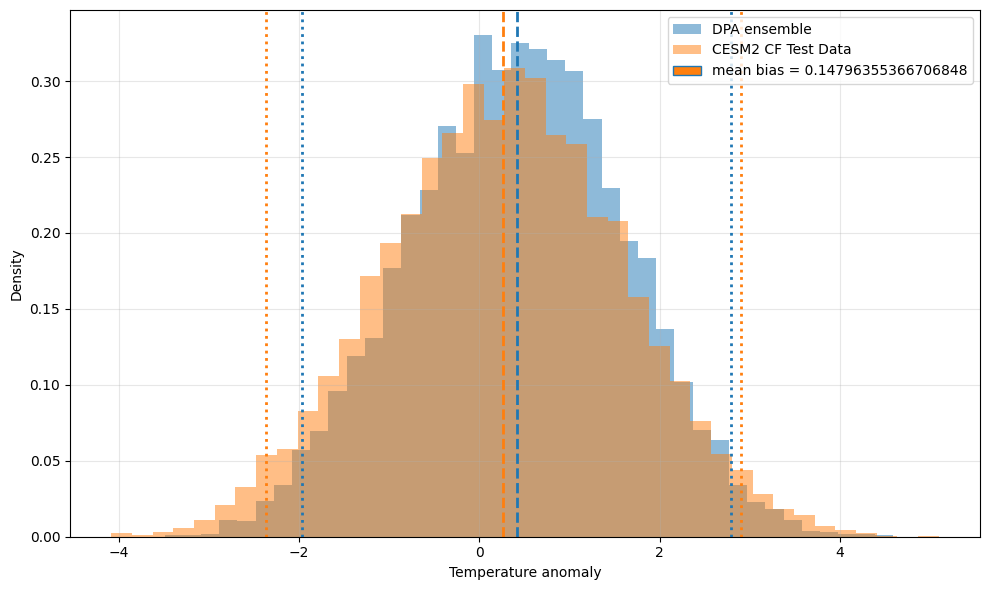

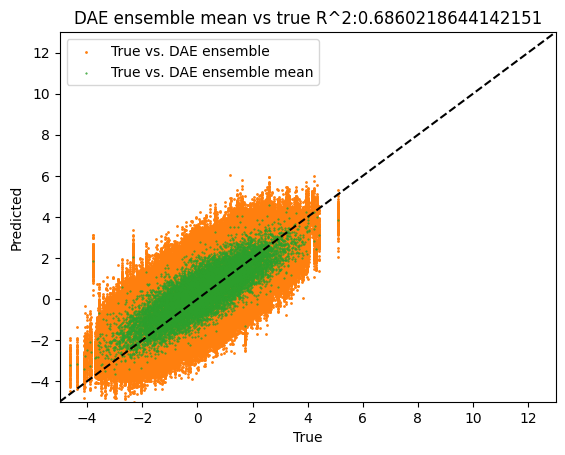

Quantiles: [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]


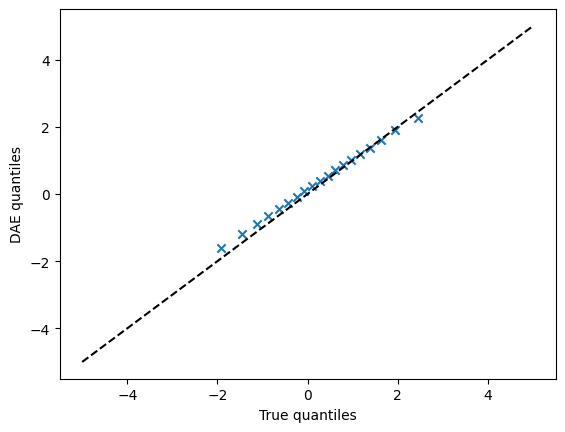

Q-Q MAE: 0.1311998845715274
C-Q MAE: 0.07231020516272857


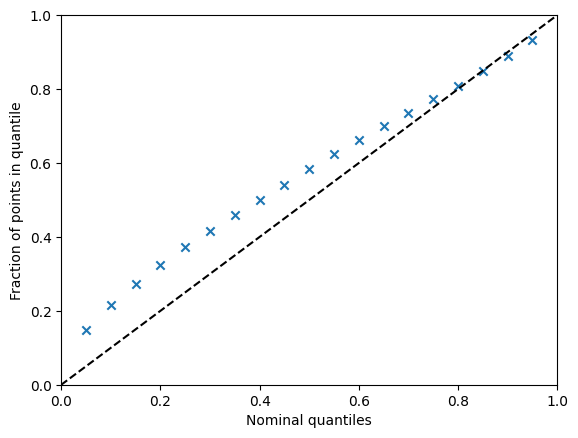

In [14]:



# fact
# Example data
# x1, x2 should be 1D arrays
x1_fact = dpa_fact
x2_fact = test_fact

fig, ax = plt.subplots(figsize=(10, 6))

# Histogram (density=True → normalized)
ax.hist(x1_fact, bins=40, density=True, alpha=0.5, label="DPA ensemble")
ax.hist(x2_fact, bins=40, density=True, alpha=0.5, label="CESM2 Fact Test Data")

# Compute statistics
mean1_fact, std1_fact = np.mean(x1_fact), np.std(x1_fact)
mean2_fact, std2_fact = np.mean(x2_fact), np.std(x2_fact)

# Add mean lines
ax.axvline(mean1_fact, linestyle="--", linewidth=2, color="tab:blue")
ax.axvline(mean2_fact, linestyle="--", linewidth=2, color ="tab:orange")

# Add ±2σ lines
ax.axvline(mean1_fact - 2*std1_fact, linestyle=":", linewidth=2, color="tab:blue")
ax.axvline(mean1_fact + 2*std1_fact, linestyle=":", linewidth=2, color="tab:blue")

ax.axvline(mean2_fact - 2*std2_fact, linestyle=":", linewidth=2, color ="tab:orange")
ax.axvline(mean2_fact + 2*std2_fact, linestyle=":", linewidth=2, color ="tab:orange")

ax.set_xlabel("Temperature anomaly")
ax.set_ylabel("Density")
ax.grid(alpha=0.3)

# legend
custom_patch = Patch(
    facecolor='tab:orange',
    edgecolor='tab:blue'
)

# Get existing legend entries
handles, labels = ax.get_legend_handles_labels()

# Append your custom entry
handles.append(custom_patch)
labels.append(f"mean bias = {np.abs(mean2_fact - mean1_fact)}")

# Rebuild legend
ax.legend(handles, labels)


plt.tight_layout()
plt.show()

# scatter predicted vs true
plt.scatter(test_fact, dpa_fact, marker='.', s=1)
y_true = test_fact
y_pred = dpa_ensemble_spat_mean_fact.T.values

N, M = y_pred.shape  # M should be 100

x = np.repeat(y_true, M)     # shape (N*100,)
y = y_pred.flatten()         # shape (N*100,)

plt.scatter(x, y, s=1, label="True vs. DAE ensemble")
plt.scatter(test_fact, dpa_fact, marker='.', s=1, label = "True vs. DAE ensemble mean")
r2_ens = 1 - np.sum((y_true - dpa_fact)**2) / np.sum((y_true - np.mean(y_true))**2)
x = np.linspace(-5, 13, 200)
# Plot 1:1 line
plt.plot(x, x, color="black", linestyle="--")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.xlim(-5,13)
plt.ylim(-5,13)
plt.title(f"DAE ensemble mean vs true R^2:{r2_ens}")
plt.legend()
plt.show()

### Factual Quantiles ###

# compute and plot quantiles
#quantiles = np.linspace(0,1,20)
quantiles = np.arange(0.05,1,0.05)
print("Quantiles:", quantiles)
quantiles_dpa_fact = np.quantile(dpa_fact, quantiles)
quantiles_test_fact = np.quantile(test_fact, quantiles)
plt.scatter(quantiles_test_fact, quantiles_dpa_fact, marker='x')
# Example data
x = np.linspace(-5, 5, 100)
# Plot 1:1 line
plt.plot(x, x, color="black", linestyle="--")
plt.xlabel("True quantiles")
plt.ylabel("DAE quantiles")
#plt.savefig("Q-Q_v6_30epochs_validation.pdf")
plt.plot()
plt.show()
mae_qq = np.mean(np.abs(quantiles_test_fact-quantiles_dpa_fact))
print("Q-Q MAE:", mae_qq)


dpa_ensemble_spat_mean_quantiles_fact = np.quantile(dpa_ensemble_spat_mean_fact, quantiles, axis=0)
cover_dpa_fact = evaluation.compute_coverage_per_quantile(test_fact, dpa_ensemble_spat_mean_quantiles_fact.T, quantiles)
plt.scatter(quantiles, cover_dpa_fact, marker='x')
plt.plot(x, x, color="black", linestyle="--")
plt.xlim(0,1)
plt.ylim(0,1)
plt.ylabel("Fraction of points in quantile")
plt.xlabel("Nominal quantiles")
mae_cq_fact = np.mean(np.abs(quantiles-cover_dpa_fact))
print("C-Q MAE:", mae_cq_fact)
#plt.savefig("cov_quants.pdf")


# CF
# Example data
# x1, x2 should be 1D arrays
x1 = dpa_cf[0:2*4769]
x2 = test_cf[0:2*4769]

fig, ax = plt.subplots(figsize=(10, 6))

# Histogram (density=True → normalized)
ax.hist(x1, bins=40, density=True, alpha=0.5, label="DPA ensemble")
ax.hist(x2, bins=40, density=True, alpha=0.5, label="CESM2 CF Test Data")

# Compute statistics
mean1, std1 = np.mean(x1), np.std(x1)
mean2, std2 = np.mean(x2), np.std(x2)

# Add mean lines
ax.axvline(mean1, linestyle="--", linewidth=2, color="tab:blue")
ax.axvline(mean2, linestyle="--", linewidth=2, color ="tab:orange")

# Add ±2σ lines
ax.axvline(mean1 - 2*std1, linestyle=":", linewidth=2, color="tab:blue")
ax.axvline(mean1 + 2*std1, linestyle=":", linewidth=2, color="tab:blue")

ax.axvline(mean2 - 2*std2, linestyle=":", linewidth=2, color ="tab:orange")
ax.axvline(mean2 + 2*std2, linestyle=":", linewidth=2, color ="tab:orange")

ax.set_xlabel("Temperature anomaly")
ax.set_ylabel("Density")
ax.grid(alpha=0.3)

# legend
custom_patch = Patch(
    facecolor='tab:orange',
    edgecolor='tab:blue'
)

# Get existing legend entries
handles, labels = ax.get_legend_handles_labels()

# Append your custom entry
handles.append(custom_patch)
labels.append(f"mean bias = {np.abs(mean2 - mean1)}")

# Rebuild legend
ax.legend(handles, labels)


plt.tight_layout()
plt.show()
#########
# scatter predicted vs true
plt.scatter(test_cf, dpa_cf, marker='.', s=1)
y_true = test_cf
y_pred = dpa_ensemble_spat_mean_cf.T.values

N, M = y_pred.shape  # M should be 100

x = np.repeat(y_true, M)     # shape (N*100,)
y = y_pred.flatten()         # shape (N*100,)

plt.scatter(x, y, s=1, label="True vs. DAE ensemble")
plt.scatter(test_cf, dpa_cf, marker='.', s=1, label = "True vs. DAE ensemble mean")
r2_ens = 1 - np.sum((x2 - x1)**2) / np.sum((x2 - np.mean(x2))**2)
x = np.linspace(-5, 13, 200)
# Plot 1:1 line
plt.plot(x, x, color="black", linestyle="--")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.xlim(-5,13)
plt.ylim(-5,13)
plt.title(f"DAE ensemble mean vs true R^2:{r2_ens}")
plt.legend()
plt.show()

### Quantiles ###

# compute and plot quantiles
#quantiles = np.linspace(0,1,20)
quantiles = np.arange(0.05,1,0.05)
print("Quantiles:", quantiles)
quantiles_dpa_cf = np.quantile(dpa_cf, quantiles)
quantiles_test_cf = np.quantile(test_cf[0:2*4769], quantiles)
plt.scatter(quantiles_test_cf, quantiles_dpa_cf, marker='x')
# Example data
x = np.linspace(-5, 5, 100)
# Plot 1:1 line
plt.plot(x, x, color="black", linestyle="--")
plt.xlabel("True quantiles")
plt.ylabel("DAE quantiles")
#plt.savefig("Q-Q_v6_30epochs_validation.pdf")
plt.plot()
plt.show()
mae_qq = np.mean(np.abs(quantiles_test_cf-quantiles_dpa_cf))
print("Q-Q MAE:", mae_qq)


dpa_ensemble_spat_mean_quantiles_cf = np.quantile(dpa_ensemble_spat_mean_cf, quantiles, axis=0)
cover_dpa_cf = evaluation.compute_coverage_per_quantile(test_cf, dpa_ensemble_spat_mean_quantiles_cf.T, quantiles)
plt.scatter(quantiles, cover_dpa_cf, marker='x')
plt.plot(x, x, color="black", linestyle="--")
plt.xlim(0,1)
plt.ylim(0,1)
plt.ylabel("Fraction of points in quantile")
plt.xlabel("Nominal quantiles")
mae_cq_cf = np.mean(np.abs(quantiles-cover_dpa_cf))
print("C-Q MAE:", mae_cq_cf)
#plt.savefig("cov_quants.pdf")


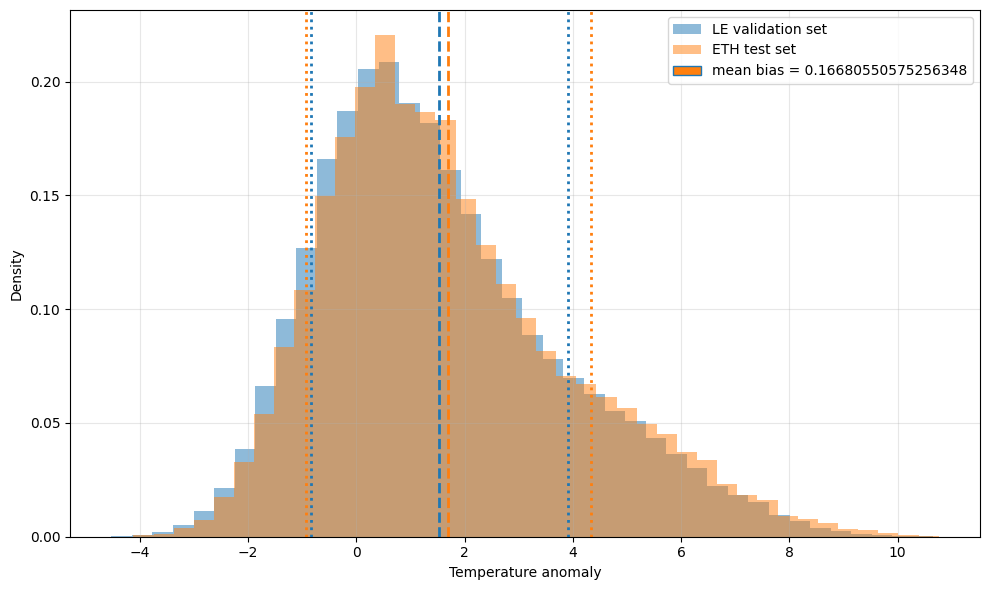

In [15]:
# MEAN BIAS between LE validation and ETH test set

# compare 

# CF
# Example data
# x1, x2 should be 1D arrays
x1_le_val = test
x2_eth_test = test_fact

fig, ax = plt.subplots(figsize=(10, 6))

# Histogram (density=True → normalized)
ax.hist(x1_le_val, bins=40, density=True, alpha=0.5, label="LE validation set")
ax.hist(x2_eth_test, bins=40, density=True, alpha=0.5, label="ETH test set")

# Compute statistics
mean1_fact, std1_fact = np.mean(x1_le_val), np.std(x1)
mean2_fact, std2_fact = np.mean(x2_eth_test), np.std(x2)

# Add mean lines
ax.axvline(mean1_fact, linestyle="--", linewidth=2, color="tab:blue")
ax.axvline(mean2_fact, linestyle="--", linewidth=2, color ="tab:orange")

# Add ±2σ lines
ax.axvline(mean1_fact - 2*std1_fact, linestyle=":", linewidth=2, color="tab:blue")
ax.axvline(mean1_fact + 2*std1_fact, linestyle=":", linewidth=2, color="tab:blue")

ax.axvline(mean2_fact - 2*std2_fact, linestyle=":", linewidth=2, color ="tab:orange")
ax.axvline(mean2_fact + 2*std2_fact, linestyle=":", linewidth=2, color ="tab:orange")

ax.set_xlabel("Temperature anomaly")
ax.set_ylabel("Density")
ax.grid(alpha=0.3)

# legend
custom_patch = Patch(
    facecolor='tab:orange',
    edgecolor='tab:blue'
)

# Get existing legend entries
handles, labels = ax.get_legend_handles_labels()

# Append your custom entry
handles.append(custom_patch)
labels.append(f"mean bias = {np.abs(mean2_fact - mean1_fact)}")

# Rebuild legend
ax.legend(handles, labels)


plt.tight_layout()
plt.show()

In [70]:
quantiles_dpa_cf

array([-1.57477479, -1.14310932, -0.85882411, -0.6273942 , -0.41916539,
       -0.23423921, -0.06499146,  0.10738798,  0.26277533,  0.41797215,
        0.56804469,  0.71913381,  0.87827467,  1.04498279,  1.20946646,
        1.40086186,  1.6180951 ,  1.89749975,  2.29631042])

In [71]:
quantiles_test_cf

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan])

In [25]:
dpa_cf.shape

(14307,)

In [26]:
test_cf.shape

(4769,)